In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('future.no_silent_downcasting', True)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import VotingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.ensemble import RandomForestRegressor

In [2]:
df4=pd.read_excel('merged_breast_cancer_data.xlsx')
df4.head(2)

,age,state,marital_status,highest_level_of_education,occupation,monthly_income,ethnic_group,who_made_you_seek_medical_help,symptions,height_cm,weight,engagement_in_physical_exercise,overall_diet,meals_taken_in_a_day,do_you_consume_alcohol,do_you_smoke,how_do_you_rate_your_stress_level,do_you_engage_in_activities_to_manage_stress,hours_of_sleep_per_night,types_of_cancer,types_of_biopsy,side,findings,categories
0,40,niger,married,tertiary,unskilled,20000,others,family or friends,change in breast size,172,77.0,little,balance,3,no,no,moderate,no,5.5,other,others,left,left breast (biopsy)- mammary ducts ectesia,Benign
1,40,kebbi,married,non-formal,unskilled,20000,hausa,family or friends,change in breast size,163,76.0,little,balance,3,no,no,moderate,no,5.5,other,others,both,bilateral breast (biopsy)- fibroadenoma,Benign


In [3]:

url = 'https://github.com/pablo9ja/NRF_work/raw/main/Breast%20Cancer%202.xlsx'
url_1 = 'https://github.com/pablo9ja/NRF_work/raw/main/Breast%20Data%2022.xlsx'
url_2 ='https://github.com/pablo9ja/NRF_work/raw/main/merged_breast_cancer_data.xlsx'

df = pd.read_excel(url).iloc[0:24]
df2 = pd.read_excel(url_1)
df4 = pd.read_excel(url_2)
print(df.shape)
print(df2.shape)
#print(df.columns.equals(df2.columns))
# Align df2 to match df's columns
df2_aligned = df2[df.columns.intersection(df2.columns)]
df2_aligned = df2_aligned.reindex(columns=df.columns)

# Concatenate
df3 = pd.concat([df, df2_aligned], ignore_index=True)

print(df3.shape)
print(df4.shape)


(24, 31)
(1030, 29)
(1054, 31)
(1054, 24)


In [4]:
df4.head(2) 

,age,state,marital_status,highest_level_of_education,occupation,monthly_income,ethnic_group,who_made_you_seek_medical_help,symptions,height_cm,weight,engagement_in_physical_exercise,overall_diet,meals_taken_in_a_day,do_you_consume_alcohol,do_you_smoke,how_do_you_rate_your_stress_level,do_you_engage_in_activities_to_manage_stress,hours_of_sleep_per_night,types_of_cancer,types_of_biopsy,side,findings,categories
0,40,niger,married,tertiary,unskilled,20000,others,family or friends,change in breast size,172,77.0,little,balance,3,no,no,moderate,no,5.5,other,others,left,left breast (biopsy)- mammary ducts ectesia,Benign
1,40,kebbi,married,non-formal,unskilled,20000,hausa,family or friends,change in breast size,163,76.0,little,balance,3,no,no,moderate,no,5.5,other,others,both,bilateral breast (biopsy)- fibroadenoma,Benign


# Data cleaning

In [5]:
extra_columns = df.columns.difference(df2.columns)
print("Extra columns:", extra_columns)

# Check for columns with more than 50% missing values in df
missing_percentage = df[extra_columns].isna().mean() * 100  # Calculate percentage of missing values

# Find columns with more than 50% missing values
columns_missing_50_plus = missing_percentage[missing_percentage > 50]
print("Columns with more than 50% missing values:", columns_missing_50_plus)


Extra columns: Index(['S/N', 'Unnamed: 30'], dtype='object')
Columns with more than 50% missing values: Unnamed: 30    87.5
dtype: float64


In [6]:
df.columns

Index(['S/N', 'NAME', 'AGE', 'GENDER', 'HOSPITAL NO', 'LAB NO', 'STATE',
       'MARITAL STATUS', 'HIGHEST LEVEL OF EDUCATION', 'OCCUPATION',
       'MONTHLY INCOME', 'ETHNIC GROUP', 'WHO MADE YOU SEEK MEDICAL HELP',
       'SYMPTIONS', 'MEDICAL CONDITIONS', 'HEIGHT (CM)', 'WEIGHT',
       'ENGAGEMENT IN PHYSICAL EXERCISE', 'OVERALL DIET',
       'MEAL(S) TAKEN IN A DAY', 'DO YOU CONSUME ALCOHOL?', 'DO YOU SMOKE?',
       'HOW DO YOU RATE YOUR STRESS LEVEL?',
       'DO YOU ENGAGE IN ACTIVITIES TO MANAGE STRESS?',
       'HOURS OF SLEEP PER NIGHT', 'TYPES OF CANCER', 'TYPES OF BIOPSY',
       'SIDE', 'GRADE OF CANCER', 'FINDINGS', 'Unnamed: 30'],
      dtype='object')

In [7]:
df2.columns

Index(['NAME', 'AGE', 'GENDER', 'HOSPITAL NO', 'LAB NO', 'STATE',
       'MARITAL STATUS', 'HIGHEST LEVEL OF EDUCATION', 'OCCUPATION',
       'MONTHLY INCOME', 'ETHNIC GROUP', 'WHO MADE YOU SEEK MEDICAL HELP',
       'SYMPTIONS', 'MEDICAL CONDITIONS', 'HEIGHT (CM)', 'WEIGHT',
       'ENGAGEMENT IN PHYSICAL EXERCISE', 'OVERALL DIET',
       'MEAL(S) TAKEN IN A DAY', 'DO YOU CONSUME ALCOHOL?', 'DO YOU SMOKE?',
       'HOW DO YOU RATE YOUR STRESS LEVEL?',
       'DO YOU ENGAGE IN ACTIVITIES TO MANAGE STRESS?',
       'HOURS OF SLEEP PER NIGHT', 'TYPES OF CANCER', 'TYPES OF BIOPSY',
       'SIDE', 'GRADE OF CANCER', 'FINDINGS'],
      dtype='object')

In [8]:
df3.columns

Index(['S/N', 'NAME', 'AGE', 'GENDER', 'HOSPITAL NO', 'LAB NO', 'STATE',
       'MARITAL STATUS', 'HIGHEST LEVEL OF EDUCATION', 'OCCUPATION',
       'MONTHLY INCOME', 'ETHNIC GROUP', 'WHO MADE YOU SEEK MEDICAL HELP',
       'SYMPTIONS', 'MEDICAL CONDITIONS', 'HEIGHT (CM)', 'WEIGHT',
       'ENGAGEMENT IN PHYSICAL EXERCISE', 'OVERALL DIET',
       'MEAL(S) TAKEN IN A DAY', 'DO YOU CONSUME ALCOHOL?', 'DO YOU SMOKE?',
       'HOW DO YOU RATE YOUR STRESS LEVEL?',
       'DO YOU ENGAGE IN ACTIVITIES TO MANAGE STRESS?',
       'HOURS OF SLEEP PER NIGHT', 'TYPES OF CANCER', 'TYPES OF BIOPSY',
       'SIDE', 'GRADE OF CANCER', 'FINDINGS', 'Unnamed: 30'],
      dtype='object')

In [9]:
for x in df3.columns:
    if df3[x].isna().sum() >200:
        print(f"{x}: {df3[x].isna().sum()} missing values")


S/N: 1030 missing values
MEDICAL CONDITIONS: 1000 missing values
GRADE OF CANCER: 505 missing values
Unnamed: 30: 1051 missing values


In [10]:
# Clean column names
df3.columns = (
    df3.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[^\w\s]', '', regex=True)
    .str.replace(r'\s+', '_', regex=True)
)
df3.head()

,sn,name,age,gender,hospital_no,lab_no,state,marital_status,highest_level_of_education,occupation,monthly_income,ethnic_group,who_made_you_seek_medical_help,symptions,medical_conditions,height_cm,weight,engagement_in_physical_exercise,overall_diet,meals_taken_in_a_day,do_you_consume_alcohol,do_you_smoke,how_do_you_rate_your_stress_level,do_you_engage_in_activities_to_manage_stress,hours_of_sleep_per_night,types_of_cancer,types_of_biopsy,side,grade_of_cancer,findings,unnamed_30
0,1.0,HABIBA YUSUF,40.0,FEMALE,BOO1,696820.0,NIGER,MARRIED,TERTIARY,UNSKILLED,"₦10,000 to ₦30,000",OTHERS,Family or friends,NaN,ULCER,172cm,77kg,Little,Balance,3.0,NO,NO,Moderate,No,5 to 6 hours,Others,Others,left,Others,Left Breast (Biopsy)- mamary ducts ectesia,NaN
1,2.0,LUBA FARUKU,40.0,FEMALE,B002,696827.0,KEBBI,MARRIED,NON FORMAL,UNSKILLED,"₦10,000 to ₦30,000",HAUSA,Family or friends,NaN,HEART DISEASE,163cm,76kg,Little,Balance,3.0,NO,NO,Moderate,No,5 to 6 hours,Others,Others,Left/Right,Others,Bilateral Breast (biopsy)- fibroadenoma,NaN
2,3.0,SUWAIBA HUSSAINI,36.0,FEMALE,B003,488640.0,KEBBI,MARRIED,NON FORMAL,UNSKILLED,"₦10,000 to ₦30,000",HAUSA,Family or friends,NaN,ULCER,158cm,60.6kg,Moderate,Balance,2.0,NO,NO,Moderate,No,5 to 6 hours,Invasive ductal carcinoma,Others,Right,Grade II,Right breast (biopsy)- Invasive ductal carcino...,NaN
3,4.0,UMAIMA IBRAHIM,65.0,FEMALE,BOO5,NaN,SOKOTO,MARRIED,PRIMARY,UNSKILLED,"₦10,000 to ₦30,000",HAUSA,Self,NaN,ULCER,159cm,58kg,Moderate,Balance,2.0,NO,NO,Moderate,No,5 to 6 hours,Invasive ductal carcinoma,Others,Right,Grade I,"Right Breast (biopsy)- resected tumour, with i...",NaN
4,5.0,SAFIYA ISAH,48.0,FEMALE,B006,NaN,KEBBI,MARRIED,TERTIARY,UNSKILLED,"₦10,000 to ₦30,000",HAUSA,Family or friends,NaN,BACK AND LEG PAIN,177cm,67kg,Moderate,Balance,3.0,NO,NO,Moderate,No,5 to 6 hours,Others,Others,Right,Grade I,Right breast (biopsy)- metaplastic carcinoma (...,NaN


In [11]:
def clean_healthcare_data(df):
    # Make a copy to avoid SettingWithCopyWarning
    df = df.copy()

    # Drop columns with more than 30% missing values
    missing_threshold = int(0.7 * len(df))
    df = df.dropna(axis=1, thresh=missing_threshold)

    # Drop specific irrelevant columns if they exist
    columns_to_drop = ['hospital_no', 'name', 'lab_no', 'gender']
    df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

    # Forward fill and backward fill missing values
    df = df.ffill().bfill()

    # Clean 'side' column only if it exists
    if 'side' in df.columns:
        df['side'] = df['side'].apply(lambda x: 'both' if isinstance(x, str) and '/' in x else x)

    # Convert all string values in the DataFrame to lowercase
    df = df.apply(lambda col: col.map(lambda x: x.lower() if isinstance(x, str) else x))

    # Clean specific columns only if they exist
    if 'engagement_in_physical_exercise' in df.columns:
        df['engagement_in_physical_exercise'] = df['engagement_in_physical_exercise'].str.strip()

    if 'age' in df.columns:
        df['age'] = pd.to_numeric(df['age'], errors='coerce').fillna(0).astype(int)

    if 'highest_level_of_education' in df.columns:
        df['highest_level_of_education'] = (
            df['highest_level_of_education']
            .replace({'non formal': 'non-formal'})
        )

    if 'height_cm' in df.columns:
        df['height_cm'] = pd.to_numeric(
            df['height_cm'].astype(str)
            .str.replace(r'\s+', '', regex=True)
            .str.replace('cm', '', regex=True),
            errors='coerce'
        )

    if 'weight' in df.columns:
        df['weight'] = pd.to_numeric(
            df['weight'].astype(str)
            .str.replace(r'\s+', '', regex=True)
            .str.replace('kg', '', regex=True),
            errors='coerce'
        )

    if 'meals_taken_in_a_day' in df.columns:
        meal_mapping = {'above': 5}
        df['meals_taken_in_a_day'] = pd.to_numeric(
            df['meals_taken_in_a_day'].replace(meal_mapping).astype(str),
            errors='coerce'
        )

    if 'hours_of_sleep_per_night' in df.columns:
        sleep_mapping = {
            'less than 5 hours': 4,
            '5 to 6 hours': 5.5,
            '7 to 8 hours': 7.5,
            'more than 8 hours': 9
        }
        df['hours_of_sleep_per_night'] = pd.to_numeric(
            df['hours_of_sleep_per_night'].replace(sleep_mapping).astype(float),
            errors='coerce'
        )

    if 'types_of_cancer' in df.columns:
        cancer_mapping = {
            'others': 'other',
            'invasive ductal carcinoma': 'invasive ductal carcinoma',
            'invasive lobular carcinoma': 'invasive lobular carcinoma',
            'medulary carcinoma': 'medullary carcinoma'
        }
        df['types_of_cancer'] = df['types_of_cancer'].replace(cancer_mapping)

    if 'monthly_income' in df.columns:
        df['monthly_income'] = (
            df['monthly_income']
            .astype(str)
            .str.lower()
            .str.replace(r'[,\s₦]+', '', regex=True)
        )
        income_map = {
            '10000to30000': 20000,
            '31000to50000': 40500,
            '51000to70000': 60500,
            '71000to90000': 80500,
            '91000andabove': 95000,
            'lessthan10000': 5000,
        }
        df['monthly_income'] = df['monthly_income'].replace(income_map)
        df['monthly_income'] = pd.to_numeric(df['monthly_income'], errors='coerce')

    return df

# Apply the cleaning function
df3 = clean_healthcare_data(df3)

In [12]:
df3.isna().sum()

age                                             0
state                                           0
marital_status                                  0
highest_level_of_education                      0
occupation                                      0
monthly_income                                  0
ethnic_group                                    0
who_made_you_seek_medical_help                  0
symptions                                       0
height_cm                                       0
weight                                          0
engagement_in_physical_exercise                 0
overall_diet                                    0
meals_taken_in_a_day                            0
do_you_consume_alcohol                          0
do_you_smoke                                    0
how_do_you_rate_your_stress_level               0
do_you_engage_in_activities_to_manage_stress    0
hours_of_sleep_per_night                        0
types_of_cancer                                 0


In [13]:
data = df['findings']

# Define categorization rules
categories = {
    'Benign': [
        'fibroadenoma', 'fibrocystic','fibrocystiic change', 'sclerosing adenosis', 'lactating adenoma','lactatonal adenoma', 'lympphocytiv mastopathy',
        'galactocide',
        'tubular adenoma','adenosis', 'intraductal papilloma', 'pseudoangiomatoid', 'adenoma','hypertrophic scar','repair tissue','cysticerosis',
        'follicle hyperplasia','benign phylloides', 'gynecomastia','gynecomastia', 'fat necrosis', 'galactocele','gynealomastia','glomangionia',
        'gynaecomasna','gygynecomasta','gynaecomastia','pubertal macromastia',
        'dermoid cyst', 'lipoma', 'intradermal nevus', 'simple cyst','follicullar','papiloma','granulomatosis','papilloma','gynaecomstrine','intraddermal nevus',
        'reactive follicular hyperplasia', 'fibrosis', 'scar tissue', 'fibroaddenoma', 'fibrocytic changes','ductal fibrocillyms','fibrocyctic disease',
        'sebacious cyst','granulation tissue', 'mammary duct ectasia', 'adenofibroma','fibrous charge','fibroadenomytoid hyperplasma','fibros-change',
        'benign','granulomrtous','phylloides','mastitis', 'granulomatous', 'abscess', 'chronic inflammation','acute inflammation', 'suppurative', 'fat necrosis',
        'foreign body','cysticercosis','inflammation', 'lactational', 'gynecomastia'
    ],
    'Malignant': [
        'invasive ductal carcinoma', 'invasive lobular carcinoma',
        'metaplastic carcinoma', 'mucinous', 'colloid', 'tubular carcinoma',' adeno-cacinoma',
        'papillary adenocarcinoma', 'medullary', 'malignant phylloides','mastatis malignancy','mastectomy','her',
        'inflammatory breast cancer', 'paget disease', 'carcinoma','resected tumour', 'malignancy','dermatofulosarcoma','duct ecision',
        'adenocarcinoma', 'metastatic carcinoma', 'lymphoma', 'fibrooadematoid hyperplasia','mammary duct ecstasia','mamary ducts ectesia',
        'dermatofibrosarcoma', 'squamous cell carcinoma', 'invasive ductal','onvasive ductal','nvasive','malignant','fibrodenoma','necrotizing fascitis',
        'atypical ductal hyperplasia', 'atypical lobular hyperplasia','radial scar', 'ductal carcinoma in situ', 'lobular carcinoma in situ',
    ],

    'Inconclusive': [
        'no malignancy', 'negative for malignancy', 'inadequate', 'see text','gradual lymphotitis','lymphotitis',
        'nos', 'no pathologic diagnosis', 'suspicious', '?','grade i', 'breast lump','reactive lymphoid hyperplasia'
    ]
}

# Function to categorize a single finding
def categorize_finding(finding):
    finding_lower = finding.lower()
    for category, keywords in categories.items():
        for keyword in keywords:
            if keyword in finding_lower:
                return category
    return 'Inconclusive'

# Categorize all findings and add the category to the DataFrame
#df3['categories'] = df3['findings'].apply(categorize_finding)
df3['findings'] = df3['findings'].apply(categorize_finding)
# Filter and count "Inconclusive" category
#inconclusive_count = df3[df3['Category'] == 'Inconclusive'].value_counts()

df3.head()


KeyError: 'findings'

## data preparation

In [ ]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054 entries, 0 to 1053
Data columns (total 24 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   age                                           1054 non-null   int64  
 1   state                                         1054 non-null   object 
 2   marital_status                                1054 non-null   object 
 3   highest_level_of_education                    1054 non-null   object 
 4   occupation                                    1054 non-null   object 
 5   monthly_income                                1054 non-null   int64  
 6   ethnic_group                                  1054 non-null   object 
 7   who_made_you_seek_medical_help                1054 non-null   object 
 8   symptions                                     1054 non-null   object 
 9   height_cm                                     1054 non-null   i

In [ ]:
df3['findings'].value_counts()

categories
Benign       566
Malignant    488
Name: count, dtype: int64

In [ ]:
# Drop rows where 'findings' contain 'Inconclusive' (case insensitive)
df3 = df3[~df3['findings'].str.contains('Inconclusive', case=False, na=False)]
df3.reset_index(drop=True, inplace=True)

df3['findings'].unique()

In [ ]:
df4.shape

(1054, 24)

In [ ]:
df4['categories'].value_counts()

categories
Benign       566
Malignant    488
Name: count, dtype: int64

## Preparing the Dataset for Predictive Machine Learning

- # Feature Engineering

In [ ]:
# Create BMI feature from height and weight
df4['bmi'] = df4['weight'] / (df4['height_cm']/100)**2

# Create age bins
df4['age_group'] = pd.cut(df4['age'], bins=[0, 30, 50, 100], labels=['young', 'middle', 'senior'])

income_bins = [0, 10000, 30000, 50000, 70000, 90000, float('inf')]
income_labels = ['very low', 'low', 'medium', 'high', 'very high', 'extremely high']

# Create income groups without NaN values
df4['income_group'] = pd.cut(df4['monthly_income'],
                            bins=income_bins,
                            labels=income_labels,
                            include_lowest=True)

In [ ]:
import pandas as pd

# Load your DataFrame (assume it's called df)
summary = df4.groupby(['do_you_consume_alcohol', 'do_you_smoke'])['categories'].value_counts().unstack().fillna(0)
print(summary)


categories                           Benign  Malignant
do_you_consume_alcohol do_you_smoke                   
no                     no             542.0      478.0
                       yes             18.0        5.0
yes                    no               6.0        4.0
                       yes              0.0        1.0


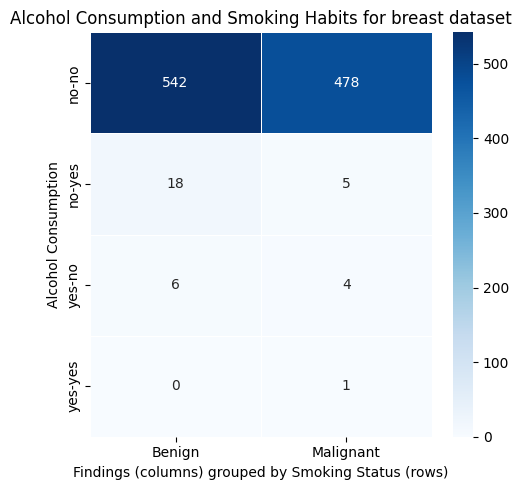

In [ ]:
# Plot the heatmap
plt.figure(figsize=(5, 5))
sns.heatmap(summary, annot=True, fmt='.0f', cmap='Blues', linewidths=.5)

plt.title('Alcohol Consumption and Smoking Habits for breast dataset')
plt.ylabel('Alcohol Consumption')
plt.xlabel('Findings (columns) grouped by Smoking Status (rows)')

plt.tight_layout()
plt.show()


C:\Users\lenovo\AppData\Local\Temp\ipykernel_10016\3566456575.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(str)



=== DATA DIAGNOSTICS ===

Postrate Cancer Risk Distribution:
cancer_risk
0    1054
Name: count, dtype: int64

Missing Values:
age                                             0
state                                           0
marital_status                                  0
highest_level_of_education                      0
occupation                                      0
monthly_income                                  0
ethnic_group                                    0
who_made_you_seek_medical_help                  0
symptions                                       0
height_cm                                       0
weight                                          0
engagement_in_physical_exercise                 0
overall_diet                                    0
meals_taken_in_a_day                            0
do_you_consume_alcohol                          0
do_you_smoke                                    0
how_do_you_rate_your_stress_level               0
do_you_engage_in_activi

c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)



monthly_income:
Correlation = nan, p-value = nan


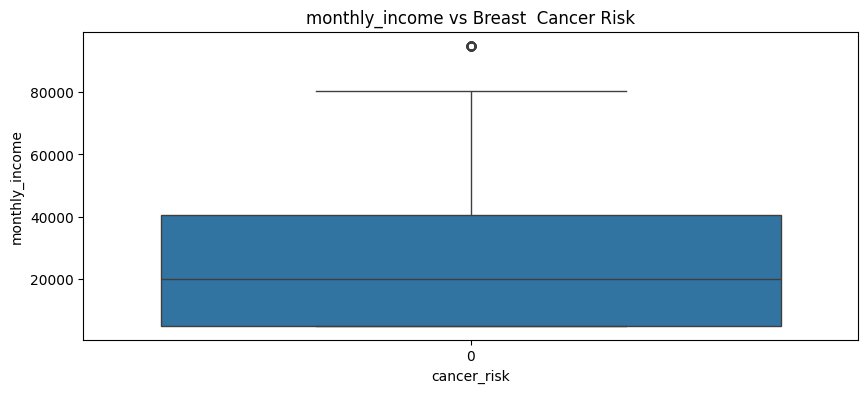

c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)



hours_of_sleep_per_night:
Correlation = nan, p-value = nan


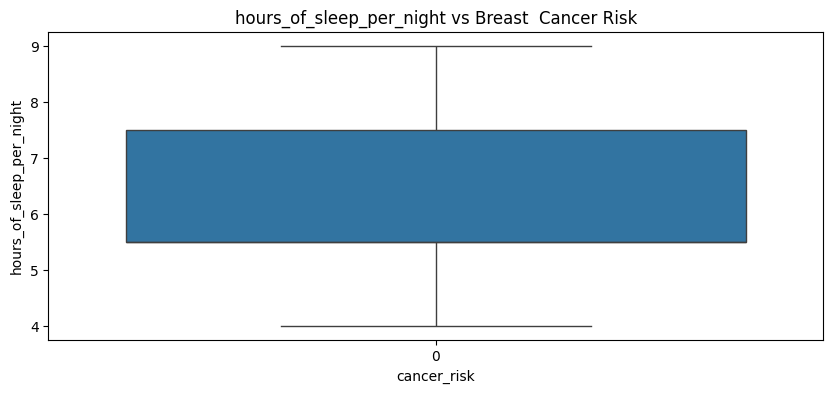

c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)



bmi:
Correlation = nan, p-value = nan


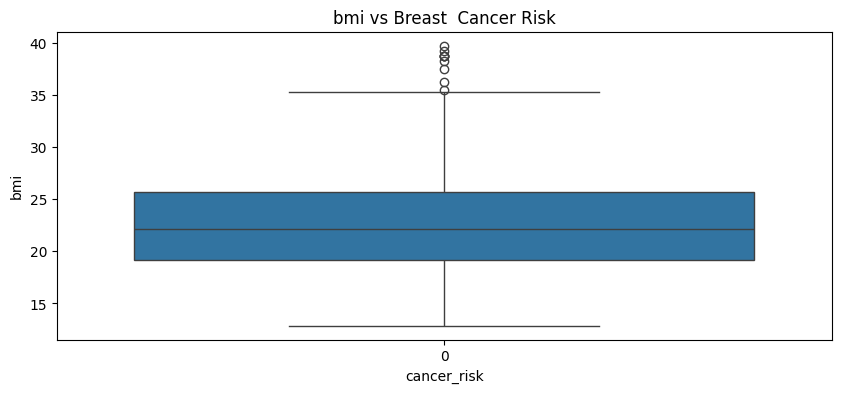

c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)



age:
Correlation = nan, p-value = nan


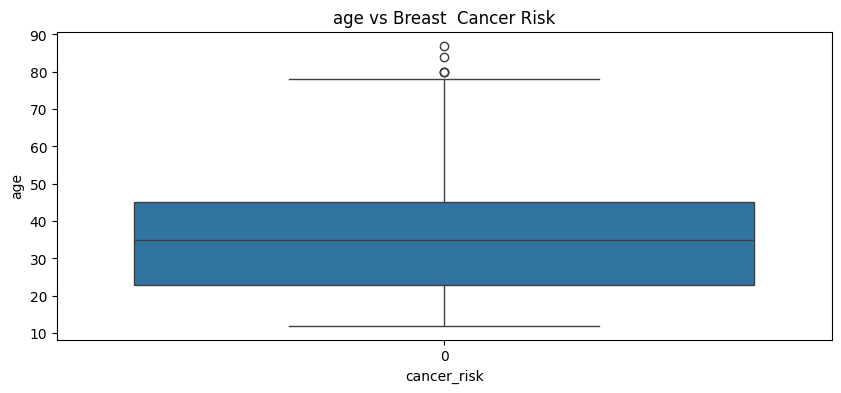


=== ADVANCED ANALYSIS ===

Urinary Symptom Prevalence:
urinary_symptoms
0    1054
Name: count, dtype: int64

Urinary Symptoms vs Breast Cancer: Chi2=0.00, p=1.0000

Analysis complete!


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, pointbiserialr
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Load and prepare data
def load_data(df):
    # Convert all columns to string type for safety
    df = df.applymap(str)
    
    # Create cancer_risk target (1=malignant, 0=benign)
    df['cancer_risk'] = df['categories'].str.lower().str.contains('cancer').astype(int)
    
    # Clean continuous variables
    cont_vars = ['monthly_income', 'hours_of_sleep_per_night', 'bmi', 'age']
    for var in cont_vars:
        if var in df.columns:
            df[var] = pd.to_numeric(df[var], errors='coerce')
    
    return df

# Diagnostic checks
def run_diagnostics(df):
    print("\n=== DATA DIAGNOSTICS ===")
    
    # 1. Check target distribution
    print("\nPostrate Cancer Risk Distribution:")
    print(df['cancer_risk'].value_counts(dropna=False))
    
    # 2. Check missing values
    print("\nMissing Values:")
    print(df.isna().sum())
    
    # 3. Check categorical variables
    cat_vars = ['overall_diet', 'do_you_consume_alcohol', 
               'do_you_smoke', 'how_do_you_rate_your_stress_level']
    print("\nCategorical Value Counts:")
    for var in cat_vars:
        if var in df.columns:
            print(f"\n{var}:")
            print(df[var].value_counts(dropna=False))
    
    # 4. Check continuous variables
    cont_vars = ['monthly_income', 'hours_of_sleep_per_night', 'bmi', 'age']
    print("\nContinuous Variable Summary:")
    print(df[cont_vars].describe())

# Lifestyle correlation analysis
def analyze_lifestyle(df):
    print("\n=== LIFESTYLE FACTOR ANALYSIS ===")
    
    # Categorical variables
    cat_vars = ['overall_diet', 'do_you_consume_alcohol', 
               'do_you_smoke', 'how_do_you_rate_your_stress_level']
    
    for var in cat_vars:
        if var in df.columns:
            # Create contingency table
            table = pd.crosstab(df[var], df['cancer_risk'])
            
            # Skip if no variation
            if table.shape[0] < 2 or table.shape[1] < 2:
                print(f"\n{var}: Cannot test - insufficient variation")
                continue
                
            # Chi-square test
            chi2, p, dof, _ = chi2_contingency(table)
            print(f"\n{var}:")
            print(f"Chi2 = {chi2:.2f}, p-value = {p:.4f}")
            print("Contingency Table:")
            print(table)
            
            # Visualize
            plt.figure(figsize=(10,4))
            sns.countplot(data=df, x=var, hue='cancer_risk')
            plt.title(f"{var} vs Breast Cancer Risk")
            plt.show()
    
    # Continuous variables
    cont_vars = ['monthly_income', 'hours_of_sleep_per_night', 'bmi', 'age']
    for var in cont_vars:
        if var in df.columns:
            # Remove missing values
            clean_df = df.dropna(subset=[var, 'cancer_risk'])
            
            # Skip if no variation
            if clean_df[var].nunique() < 2:
                print(f"\n{var}: Cannot test - no variation")
                continue
                
            # Point-biserial correlation
            corr, p = pointbiserialr(clean_df[var], clean_df['cancer_risk'])
            print(f"\n{var}:")
            print(f"Correlation = {corr:.2f}, p-value = {p:.4f}")
            
            # Visualize
            plt.figure(figsize=(10,4))
            sns.boxplot(data=clean_df, x='cancer_risk', y=var)
            plt.title(f"{var} vs Breast  Cancer Risk")
            plt.show()

# Advanced analysis
def advanced_analysis(df):
    print("\n=== ADVANCED ANALYSIS ===")
    
    # 1. Symptom analysis
    if 'symptions' in df.columns:
        df['urinary_symptoms'] = df['symptions'].str.lower().str.contains(
            'dribbling|nocturia|frequent urination', regex=True).astype(int)
        
        # Check symptom prevalence
        print("\nUrinary Symptom Prevalence:")
        print(df['urinary_symptoms'].value_counts())
        
        # Correlation with cancer
        if 'cancer_risk' in df.columns:
            table = pd.crosstab(df['urinary_symptoms'], df['cancer_risk'])
            chi2, p, _, _ = chi2_contingency(table)
            print(f"\nUrinary Symptoms vs Breast Cancer: Chi2={chi2:.2f}, p={p:.4f}")
    
    # 2. Predictive modeling
    try:
        features = ['age', 'bmi', 'urinary_symptoms'] 
        features = [f for f in features if f in df.columns]
        
        if features and 'cancer_risk' in df.columns:
            X = df[features].fillna(df[features].median())
            y = df['cancer_risk']
            
            if y.nunique() > 1:
                X_train, X_test, y_train, y_test = train_test_split(
                    X, y, test_size=0.3, random_state=42)
                
                model = RandomForestClassifier()
                model.fit(X_train, y_train)
                
                print("\nPrediction Model Performance:")
                print(classification_report(y_test, model.predict(X_test)))
                
                print("\nFeature Importances:")
                for name, imp in zip(features, model.feature_importances_):
                    print(f"{name}: {imp:.2f}")
    except Exception as e:
        print(f"\nModeling failed: {str(e)}")

# Main execution
if __name__ == "__main__":
    # Load your data
    # df = pd.read_csv('your_data.csv')  # Uncomment to load from file
    # Or use your existing DataFrame:
    df = df4.copy()  # Replace df3 with your actual DataFrame name
    
    # Clean and prepare data
    df = load_data(df)
    
    # Run diagnostics
    run_diagnostics(df)
    
    # Core analysis
    analyze_lifestyle(df)
    
    # Advanced analysis
    advanced_analysis(df)
    
    print("\nAnalysis complete!")

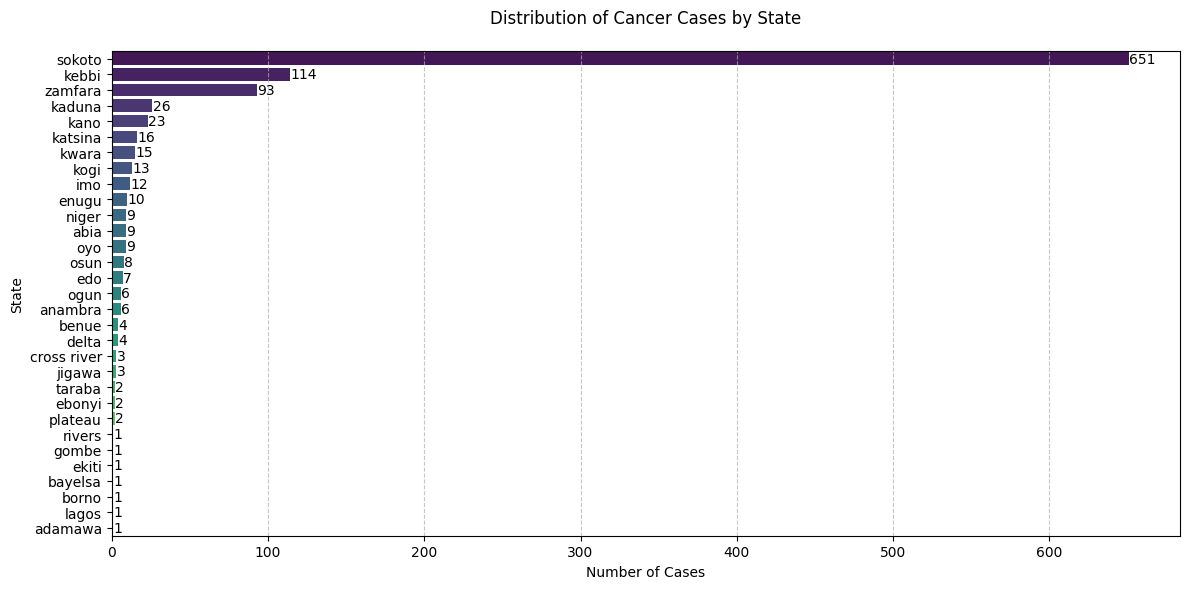

In [ ]:
state_counts = df4['state'].value_counts()

# Create bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=state_counts.values,
            y=state_counts.index,
            hue=state_counts.index,  # Added hue
            palette='viridis',
            legend=False)  # Disable legend since we don't need it

plt.title('Distribution of Cancer Cases by State', pad=20)
plt.xlabel('Number of Cases')
plt.ylabel('State')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add value labels
for i, v in enumerate(state_counts.values):
    plt.text(v + 0.2, i, str(v), color='black', va='center')

plt.tight_layout()
plt.show()

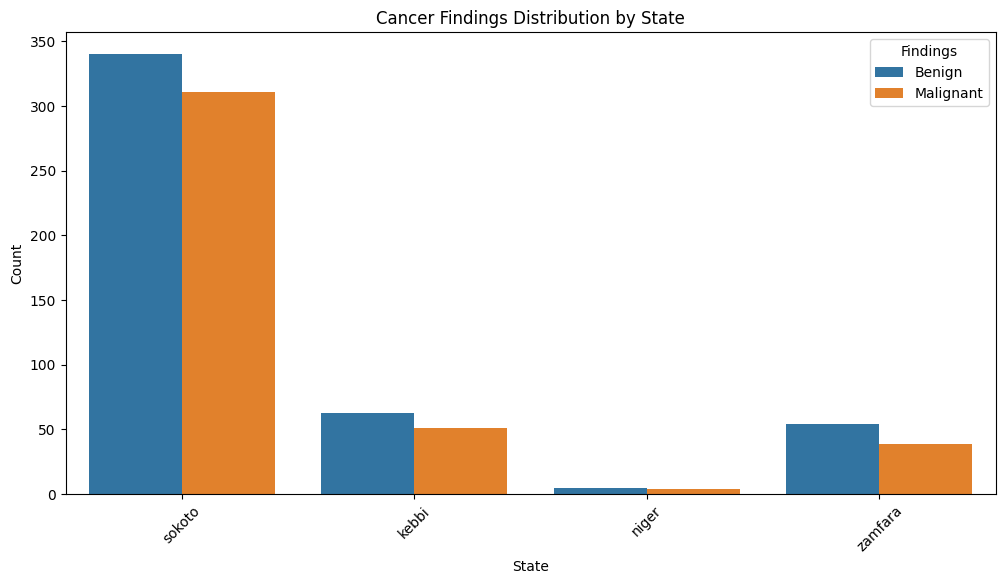

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df4, x='state', hue='categories', order=df4['state'].head(20).value_counts().index)
plt.title('Cancer Findings Distribution by State')
plt.xlabel('State')
plt.ylabel('Count')
plt.legend(title='Findings')
plt.xticks(rotation=45)
plt.show()

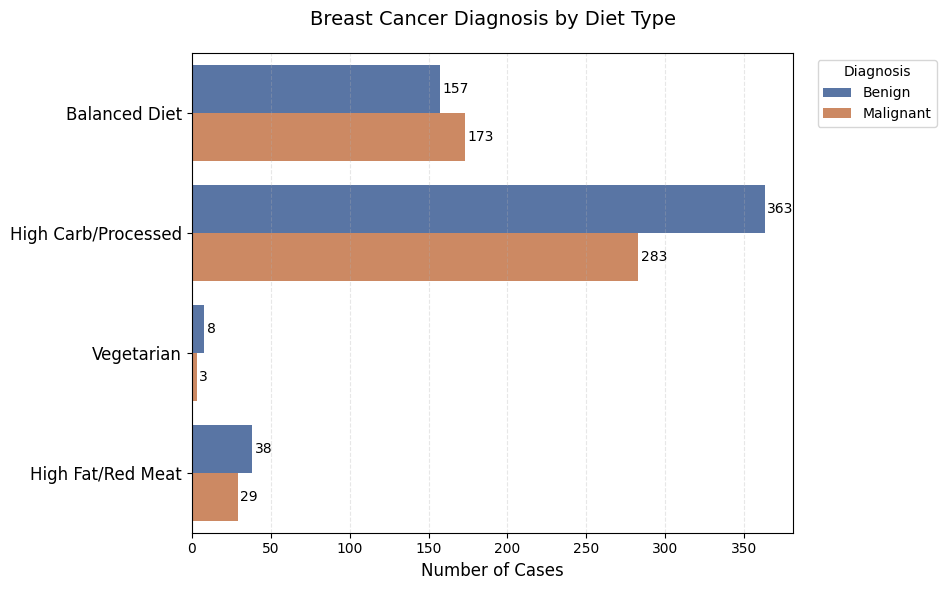

In [ ]:
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

# Define diet labels
diet_labels = {
    'balance': 'Balanced Diet',
    'high in carbohydrate and processed foods': 'High Carb/Processed',
    'vegetarian': 'Vegetarian',
    'high in fat and red meat': 'High Fat/Red Meat'
}

# Define complete findings palette
categories_palette = {
    'Benign': '#4c72b0',
    'Malignant': '#dd8452',
    'Inconclusive': '#7f7f7f'
}

# Create plot
plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=df4,
    y='overall_diet',
    hue='categories',
    order=list(diet_labels.keys()),
    palette=categories_palette
)

# Customize y-axis labels
plt.yticks(
    ticks=range(len(diet_labels)),
    labels=[diet_labels[d] for d in diet_labels.keys()],
    fontsize=12
)

# Add titles and labels
plt.title('Breast Cancer Diagnosis by Diet Type', pad=20, fontsize=14)
plt.xlabel('Number of Cases', fontsize=12)
plt.ylabel('')
plt.legend(title='Diagnosis', bbox_to_anchor=(1.25, 1))

# Add count labels
for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=2, fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

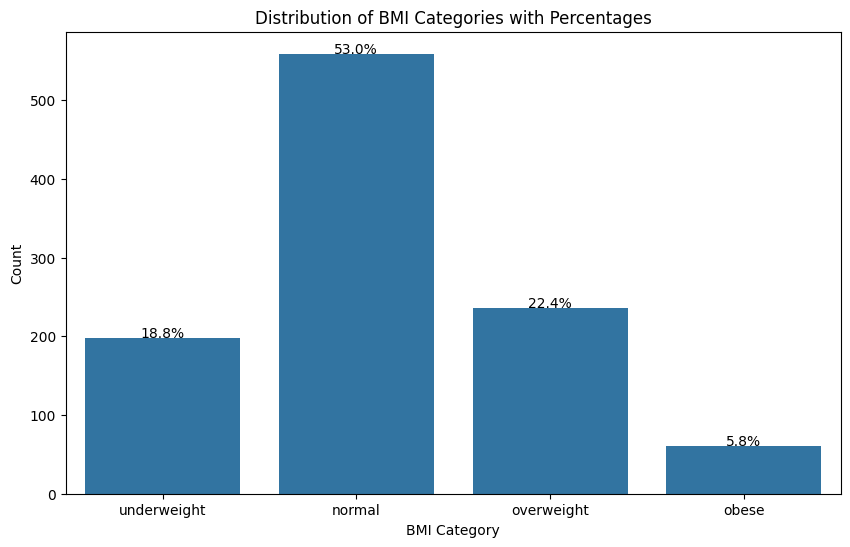

In [ ]:
def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'underweight'
    elif 18.5 <= bmi < 25:
        return 'normal'
    elif 25 <= bmi < 30:
        return 'overweight'
    else:
        return 'obese'

bmi= df4['bmi'].apply(categorize_bmi)
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df4, x=bmi, order=['underweight', 'normal', 'overweight', 'obese'])

# Add percentages on top of bars
total = len(df3)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width()/2
    y = p.get_height() + 0.5
    ax.annotate(percentage, (x, y), ha='center')

plt.title('Distribution of BMI Categories with Percentages')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.show()

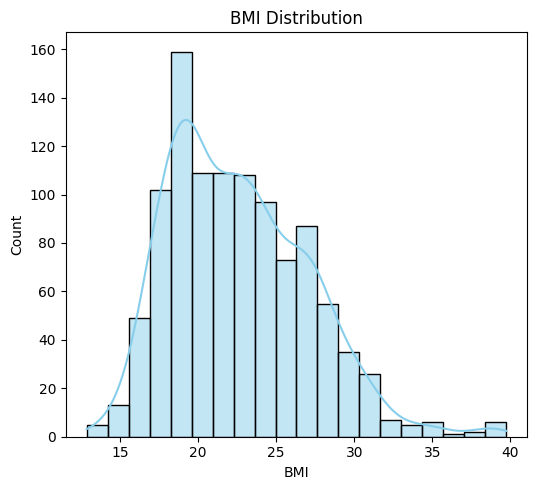

In [ ]:
plt.figure(figsize=(15, 5))

# Histogram with KDE
plt.subplot(1, 3, 1)
sns.histplot(df4['bmi'], bins=20, kde=True, color='skyblue')
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Count')


plt.tight_layout()
plt.show()

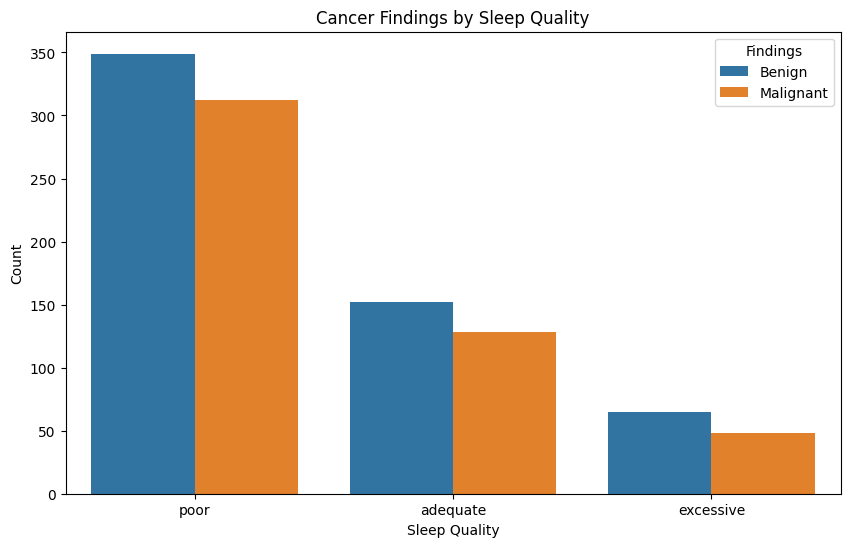

In [ ]:
def sleep_quality(hours):
    if hours < 6:
        return 'poor'
    elif 6 <= hours < 8:
        return 'adequate'
    else:
        return 'excessive'

sleep_quality = df4['hours_of_sleep_per_night'].apply(sleep_quality)

# Create plot
plt.figure(figsize=(10,6))
sns.countplot(data=df4, x=sleep_quality, hue='categories',
             order=['poor', 'adequate', 'excessive'])
plt.title('Cancer Findings by Sleep Quality')
plt.xlabel('Sleep Quality')
plt.ylabel('Count')
plt.legend(title='Findings')
plt.show()

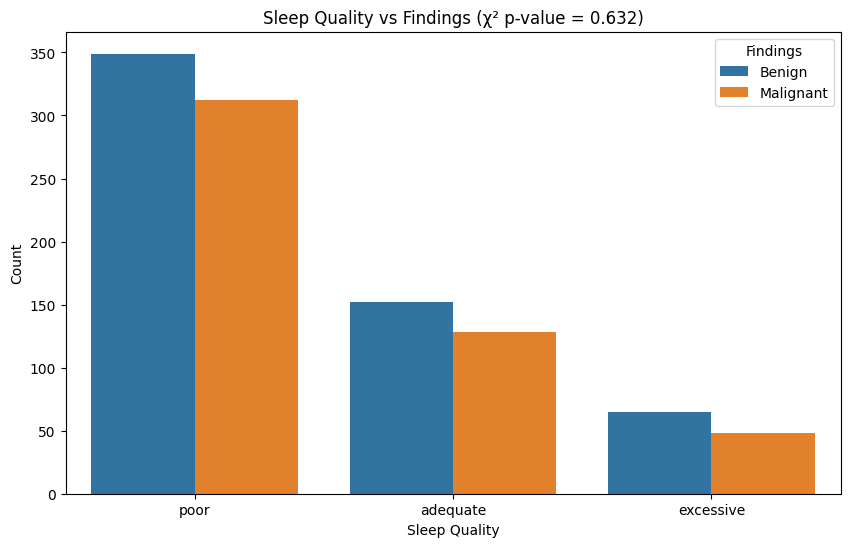

In [ ]:
from scipy.stats import chi2_contingency

# Chi-square test
contingency_table = pd.crosstab(sleep_quality, df4['categories'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Plot with statistical annotation
plt.figure(figsize=(10,6))
ax = sns.countplot(data=df4, x=sleep_quality, hue='categories',
                  order=['poor', 'adequate', 'excessive'])
plt.title(f'Sleep Quality vs Findings (χ² p-value = {p:.3f})')
plt.xlabel('Sleep Quality')
plt.ylabel('Count')
plt.legend(title='Findings')
plt.show()

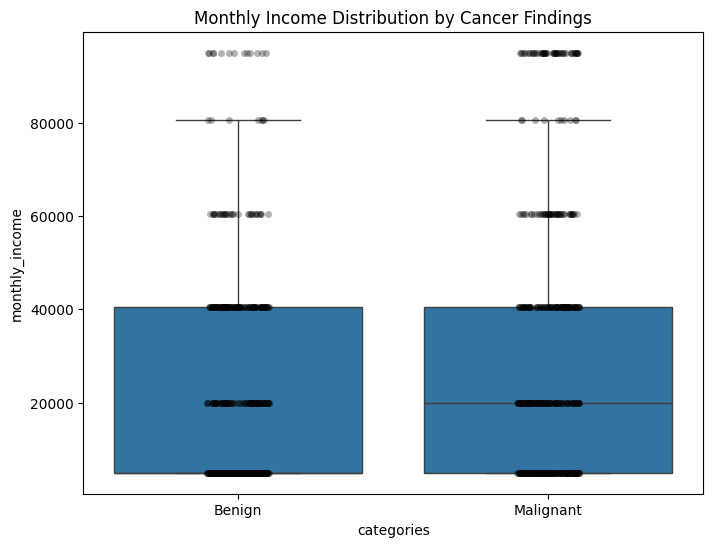

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df4, x='categories', y='monthly_income', showfliers=False)
sns.stripplot(data=df4, x='categories', y='monthly_income', color='black', alpha=0.3, jitter=True)
plt.title('Monthly Income Distribution by Cancer Findings')
plt.show()

KeyError: 'income_group'

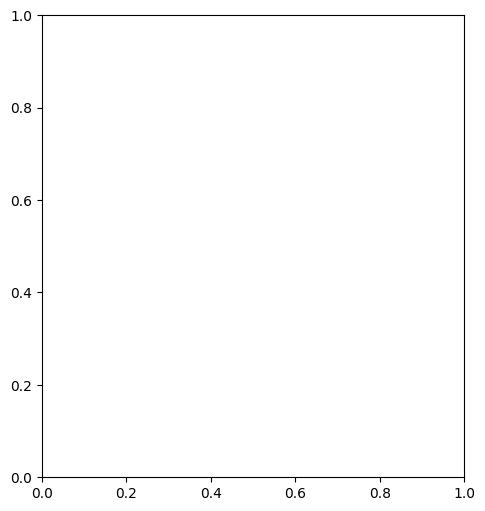

In [ ]:
plt.figure(figsize=(12, 6))

# Left plot - count by income group
plt.subplot(1, 2, 1)
df3['income_group'].value_counts().sort_index().plot(
    kind='bar')
plt.title('Count by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Count')
plt.xticks(rotation=45)



plt.tight_layout()
plt.show()

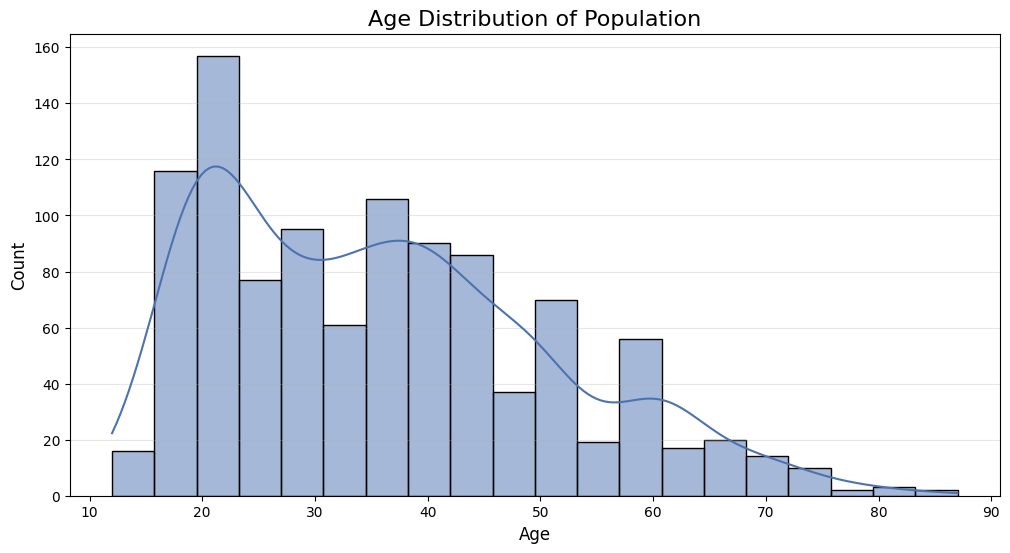

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df4, x='age', bins=20, kde=True, color='#4c72b0')
plt.title('Age Distribution of Population', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

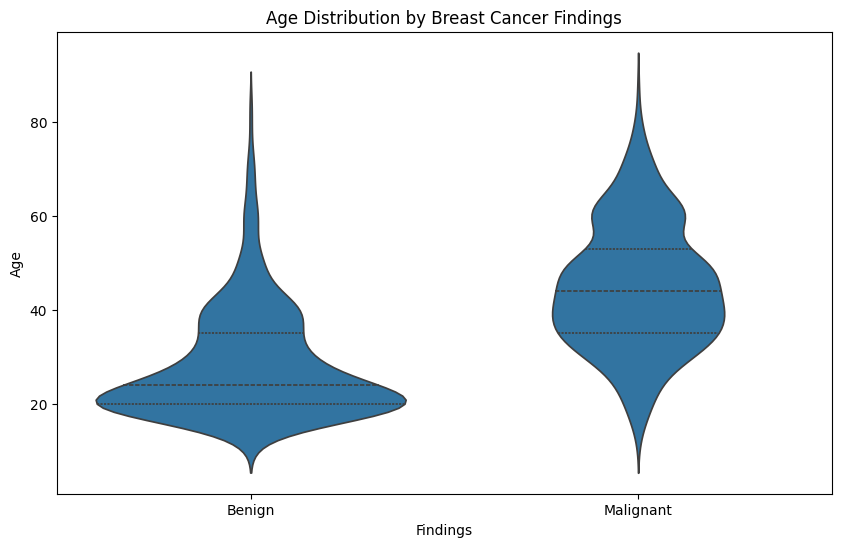

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df4, x='categories', y='age', inner='quartile')
plt.title('Age Distribution by Breast Cancer Findings')
plt.xlabel('Findings')
plt.ylabel('Age')
plt.show()

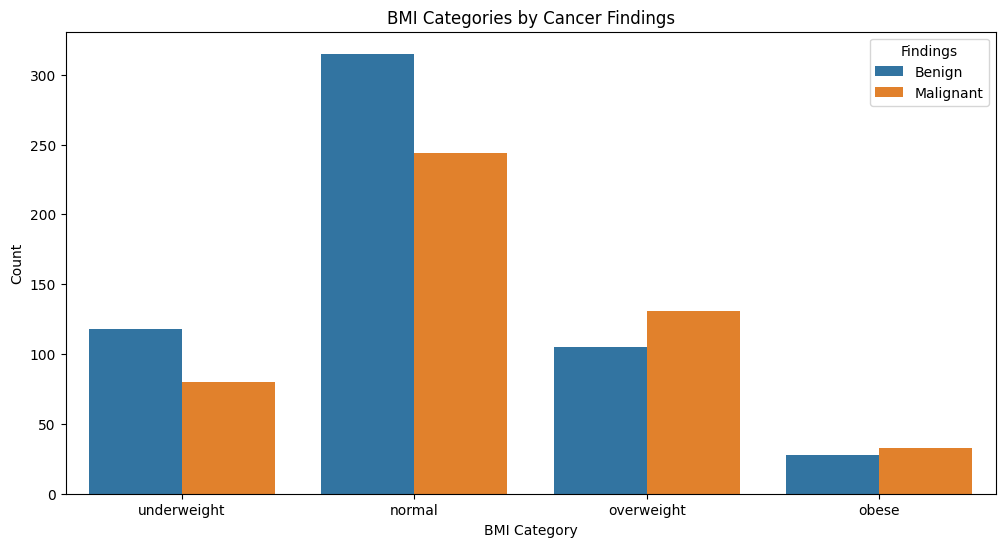

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df4, x= bmi, hue='categories',
             order=['underweight', 'normal', 'overweight', 'obese'])
plt.title('BMI Categories by Cancer Findings')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.legend(title='Findings')
plt.show()

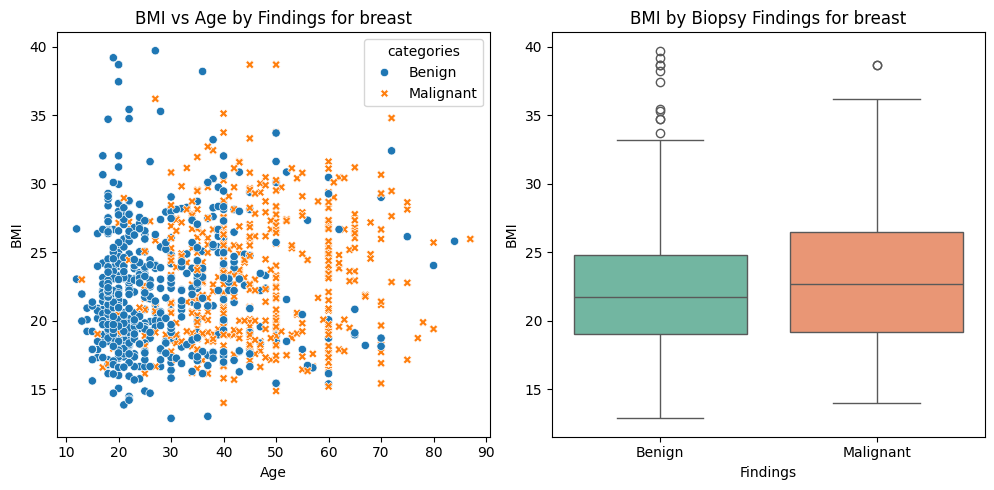

In [ ]:
plt.figure(figsize=(15, 5))

# BMI vs Age
plt.subplot(1, 3, 1)
sns.scatterplot(x='age', y='bmi', data=df4, hue='categories', style='categories')
plt.title('BMI vs Age by Findings for breast')
plt.xlabel('Age')
plt.ylabel('BMI')

# BMI vs Findings (target variable)
plt.subplot(1, 3, 2)
sns.boxplot(x='categories', y='bmi', data=df4,
            hue='categories', palette='Set2', legend=False)
plt.title('BMI by Biopsy Findings for breast')
plt.xlabel('Findings')
plt.ylabel('BMI')

plt.tight_layout()
plt.show()

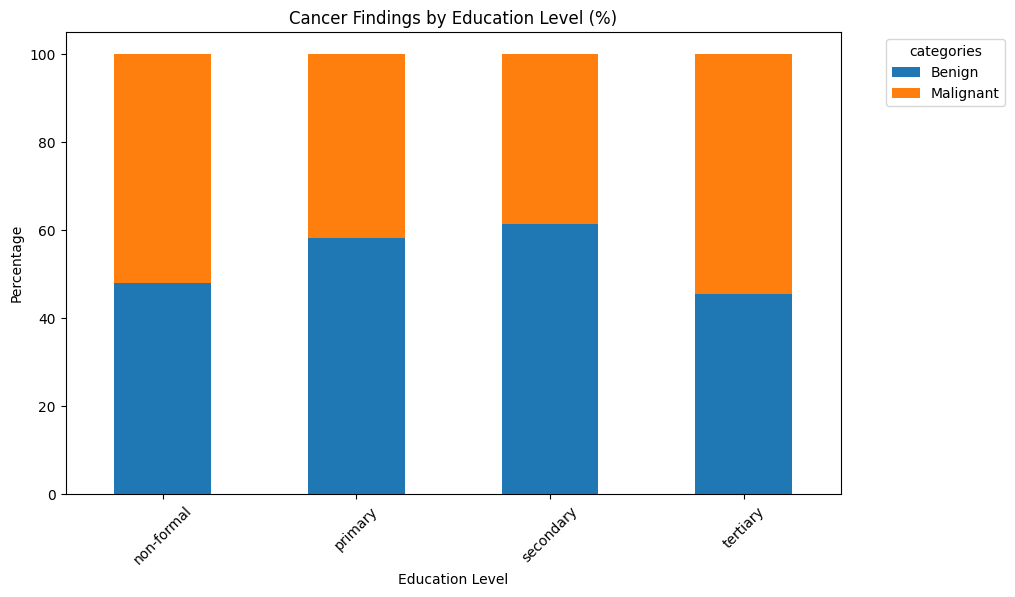

In [ ]:
# Calculate percentages
edu_findings = pd.crosstab(df4['highest_level_of_education'], df4['categories'], normalize='index') * 100

# Plot
edu_findings.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Cancer Findings by Education Level (%)')
plt.xlabel('Education Level')
plt.ylabel('Percentage')
plt.legend(title='categories', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.show()

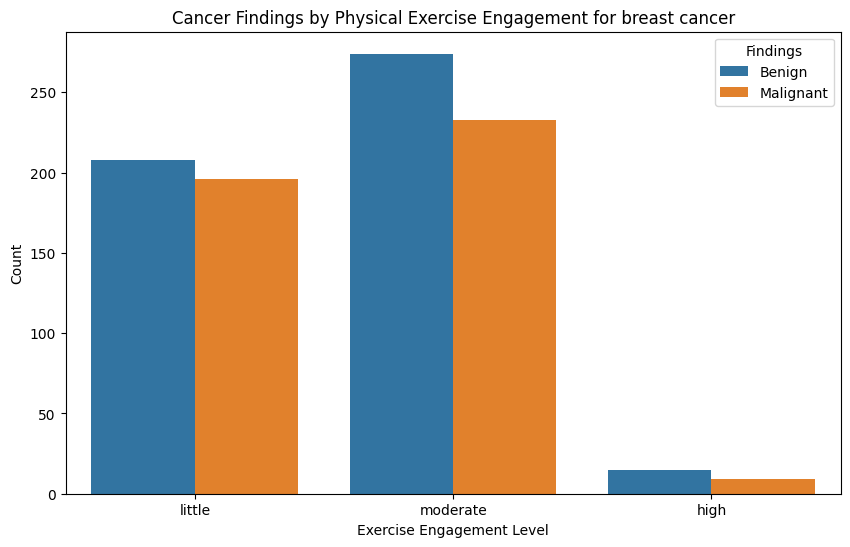

In [ ]:

plt.figure(figsize=(10,6))
sns.countplot(data=df4, x='engagement_in_physical_exercise', hue='categories',
             order=['little', 'moderate', 'high'])
plt.title('Cancer Findings by Physical Exercise Engagement for breast cancer')
plt.xlabel('Exercise Engagement Level')
plt.ylabel('Count')
plt.legend(title='Findings')
plt.show()

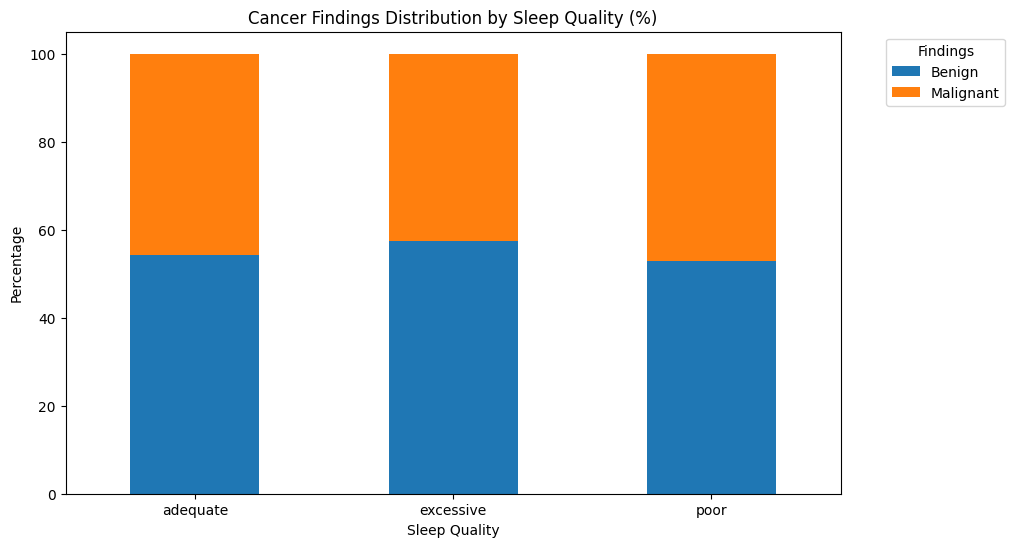

In [ ]:
# Calculate percentages
sleep_findings = pd.crosstab(sleep_quality, df4['categories'], normalize='index') * 100

# Plot
sleep_findings.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Cancer Findings Distribution by Sleep Quality (%)')
plt.xlabel('Sleep Quality')
plt.ylabel('Percentage')
plt.legend(title='Findings', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
plt.show()

In [ ]:
url_2 ='https://github.com/pablo9ja/NRF_work/raw/main/merged_breast_cancer_data.xlsx'

df4 = pd.read_excel(url_2)

print(df4.shape)
df4.head(2)


(1054, 24)


,age,state,marital_status,highest_level_of_education,occupation,monthly_income,ethnic_group,who_made_you_seek_medical_help,symptions,height_cm,weight,engagement_in_physical_exercise,overall_diet,meals_taken_in_a_day,do_you_consume_alcohol,do_you_smoke,how_do_you_rate_your_stress_level,do_you_engage_in_activities_to_manage_stress,hours_of_sleep_per_night,types_of_cancer,types_of_biopsy,side,,categories
0,40,niger,married,tertiary,unskilled,20000,others,family or friends,change in breast size,172,77.0,little,balance,3,no,no,moderate,no,5.5,other,others,left,left breast (biopsy)- mammary ducts ectesia,Benign
1,40,kebbi,married,non-formal,unskilled,20000,hausa,family or friends,change in breast size,163,76.0,little,balance,3,no,no,moderate,no,5.5,other,others,both,bilateral breast (biopsy)- fibroadenoma,Benign


# DataSet

# Encoding Categorical Variables

In [1]:
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier

def preprocess_and_select_features(
    filepath,
    target_col='categories',
    drop_cols=['findings'],
    variance_thresh=0.1,
    importance_thresh=0.01
):
    """
    Loads Excel data, pre-processes (drops missing/cols, encodes),
    and performs feature selection using VarianceThreshold and RandomForest.

    Returns:
        X_encoded: One-hot encoded features
        y_encoded: Encoded target
        X_selected: Features after VarianceThreshold
        important_features: Names of features deemed important by RF
    """
    # Load data
    df = pd.read_excel(filepath)
    # Drop missing target values
    df = df.dropna(subset=[target_col])
    # Drop specified columns if present
    for col in drop_cols:
        if col in df.columns:
            df = df.drop(columns=[col])
    # Separate features and target
    X = df.drop(columns=[target_col])
    y_encoded = df[target_col].map({'Benign': 1, 'Malignant': 0})
    # One-hot encode features
    X_encoded = pd.get_dummies(X, drop_first=True)

    # VarianceThreshold feature selection
    selector = VarianceThreshold(threshold=variance_thresh)
    X_selected = selector.fit_transform(X_encoded)
    selected_columns = X_encoded.columns[selector.get_support()]

    # Random Forest feature importances
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_encoded, y_encoded)
    importances = rf.feature_importances_
    important_features = X_encoded.columns[importances > importance_thresh]

    # Print previews and summaries
    print("Encoded features preview:\n", X_encoded.head(2))
    print("Encoded target value counts:\n", y_encoded.value_counts())
    print("Missing target labels after cleaning:", y_encoded.isnull().sum())
    print("VarianceThreshold selected columns:\n", list(selected_columns))
    print("Random Forest important features (>thresh):\n", list(important_features))
    return X_encoded, y_encoded, X_selected, list(important_features)

# Example usage:
X_encoded, y_encoded, X_selected, important_features = preprocess_and_select_features('merged_breast_cancer_data.xlsx')


Encoded features preview:
    age  monthly_income  height_cm  weight  meals_taken_in_a_day  \
0   40           20000        172    77.0                     3   
1   40           20000        163    76.0                     3   

   hours_of_sleep_per_night  state_adamawa  state_anambra  state_bayelsa  \
0                       5.5          False          False          False   
1                       5.5          False          False          False   

   state_benue  ...  types_of_cancer_medullary carcinoma  \
0        False  ...                                False   
1        False  ...                                False   

   types_of_cancer_more than 8 hours  types_of_cancer_other  \
0                              False                   True   
1                              False                   True   

   types_of_biopsy_mastectomy  types_of_biopsy_others  \
0                       False                    True   
1                       False                    True   


# Train a Baseline Model

Test Accuracy: 0.9052132701421801
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.83      0.89       102
           1       0.86      0.97      0.91       109

    accuracy                           0.91       211
   macro avg       0.91      0.90      0.90       211
weighted avg       0.91      0.91      0.90       211

Confusion Matrix:
 [[ 85  17]
 [  3 106]]
ROC AUC Score: 0.961548839719374


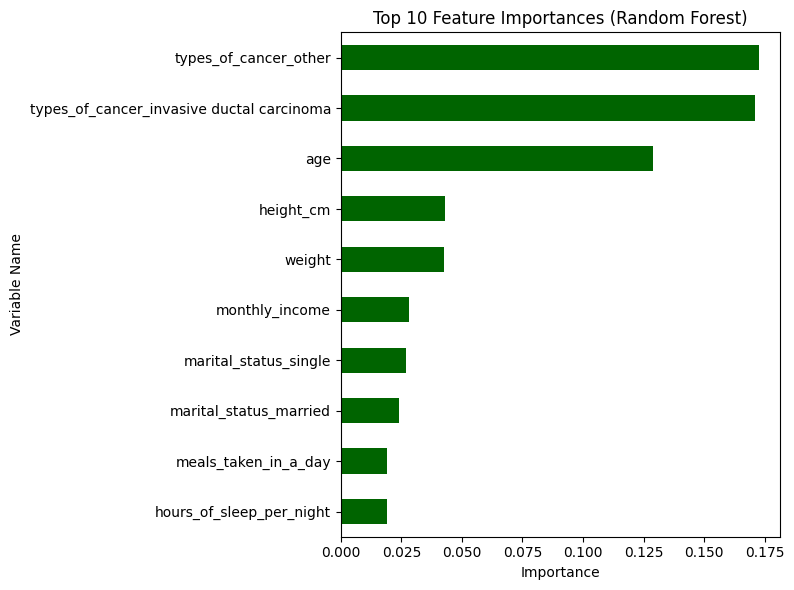


Top Feature Importances:
types_of_cancer_other: 0.173
types_of_cancer_invasive ductal carcinoma: 0.171
age: 0.129
height_cm: 0.043
weight: 0.043
monthly_income: 0.028
marital_status_single: 0.027
marital_status_married: 0.024
meals_taken_in_a_day: 0.019
hours_of_sleep_per_night: 0.019

First 10 predictions (actual/predicted/probability):
      Actual  Predicted  Probability_Class1
260        1          1                0.74
1025       0          0                0.39
845        1          1                0.93
1005       1          1                0.90
88         1          1                0.75
457        0          0                0.10
184        0          0                0.10
986        1          1                0.85
367        0          0                0.09
558        0          0                0.34

Number of misclassified samples: 20
     Actual  Predicted  Probability_Class1
296       0          1                0.79
694       0          1                0.74
802      

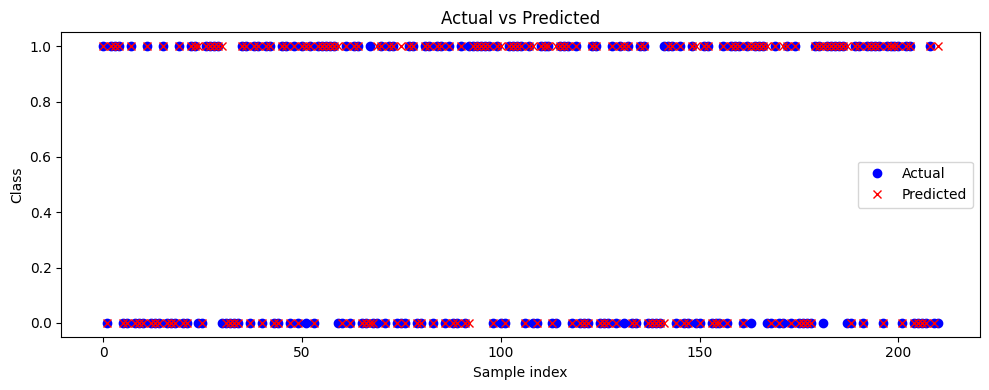

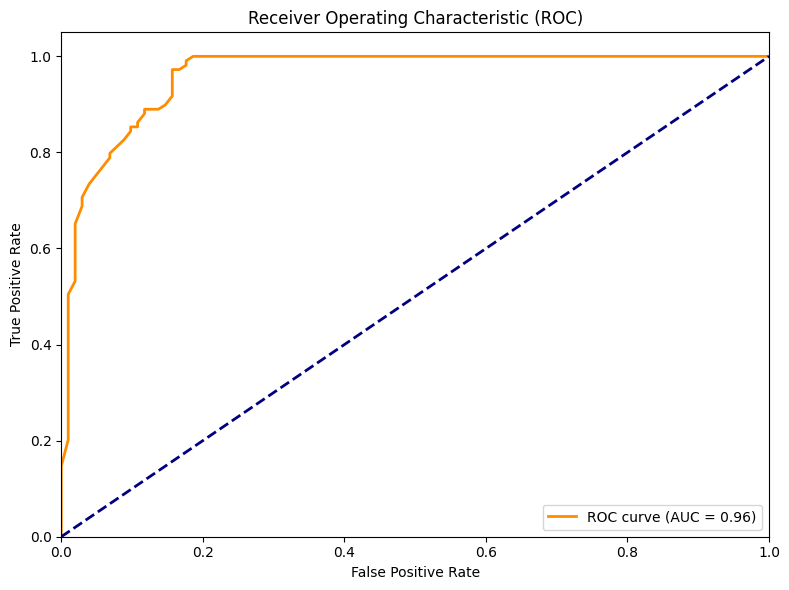

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

def random_forest_full_evaluation(
    X, y, feature_names=None, n_top_features=10, test_size=0.2, random_state=42
):
    """
    Trains a Random Forest classifier, prints and plots metrics/results,
    including feature importance (with variable names), ROC curve,
    misclassifications, and actual vs. predicted plot.

    Parameters:
        X (pd.DataFrame or np.ndarray): Feature matrix (after any selection); shape (n_samples, n_features)
        y (pd.Series or np.ndarray): Target vector
        feature_names (list or pd.Index, optional): Names of the features in X,
            REQUIRED if X is a NumPy array or after VarianceThreshold
        n_top_features (int): Number of top features to plot by importance
        test_size (float): Test set proportion for split
        random_state (int): For reproducibility

    Returns:
        rf_model: Fitted Random Forest model
        results_df: DataFrame of Actual, Predicted, Probability
        misclassified_df: DataFrame of misclassified samples
    """
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Train RF model
    rf_model = RandomForestClassifier(random_state=random_state)
    rf_model.fit(X_train, y_train)

    # Make predictions
    y_pred = rf_model.predict(X_test)
    y_proba = rf_model.predict_proba(X_test)[:, 1]

    # Print metrics
    print("Test Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

    # Feature importance
    importances = rf_model.feature_importances_
    if feature_names is None:
        # Use DataFrame columns if present, otherwise fallback to generic
        if hasattr(X, "columns"):
            feature_names = X.columns
        else:
            feature_names = [f"Feature {i}" for i in range(X.shape[1])]
    # Plot feature importances using provided/given names
    feat_importances = pd.Series(importances, index=feature_names)
    plt.figure(figsize=(8, 6))
    feat_importances.nlargest(n_top_features).plot(kind='barh', color='darkgreen')
    plt.title(f"Top {n_top_features} Feature Importances (Random Forest)")
    plt.xlabel("Importance")
    plt.ylabel("Variable Name")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    # Print top importances
    print("\nTop Feature Importances:")
    for name, val in feat_importances.nlargest(n_top_features).items():
        print(f"{name}: {val:.3f}")

    # Create DataFrame with actual and predicted values
    results_df = pd.DataFrame({
        'Actual': y_test if isinstance(y_test, (pd.Series, pd.DataFrame)) else pd.Series(y_test),
        'Predicted': y_pred,
        'Probability_Class1': y_proba
    })
    print("\nFirst 10 predictions (actual/predicted/probability):")
    print(results_df.head(10))

    # Misclassified samples
    misclassified_df = results_df[results_df['Actual'] != results_df['Predicted']]
    print(f"\nNumber of misclassified samples: {len(misclassified_df)}")
    print(misclassified_df)

    # Actual vs Predicted plot
    plt.figure(figsize=(10, 4))
    plt.plot(results_df['Actual'].values, 'bo', label='Actual')
    plt.plot(results_df['Predicted'].values, 'rx', label='Predicted')
    plt.legend()
    plt.xlabel('Sample index')
    plt.ylabel('Class')
    plt.title('Actual vs Predicted')
    plt.tight_layout()
    plt.show()

    # ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    # Return useful objects for downstream use
    return rf_model, results_df, misclassified_df
rf_model, results_df, misclassified_df = random_forest_full_evaluation(
    X_encoded, y_encoded
)


# Supporting Vector Regression Model

SVC Test Accuracy: 0.9146919431279621
SVC Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.83      0.90       102
           1       0.86      0.99      0.92       109

    accuracy                           0.91       211
   macro avg       0.93      0.91      0.91       211
weighted avg       0.92      0.91      0.91       211

SVC Confusion Matrix:
 [[ 85  17]
 [  1 108]]
SVC ROC AUC Score: 0.9527792768483541
Sample Predictions:
     Actual  Predicted  Probability_Class1
0        1          1            0.861184
1        0          0            0.049512
2        1          1            0.863113
3        1          1            0.864044
4        1          1            0.889797
5        0          0            0.042909
6        0          0            0.017121
7        1          1            0.909008
8        0          0            0.026826
9        0          0            0.157850
10       0          0            0.03050

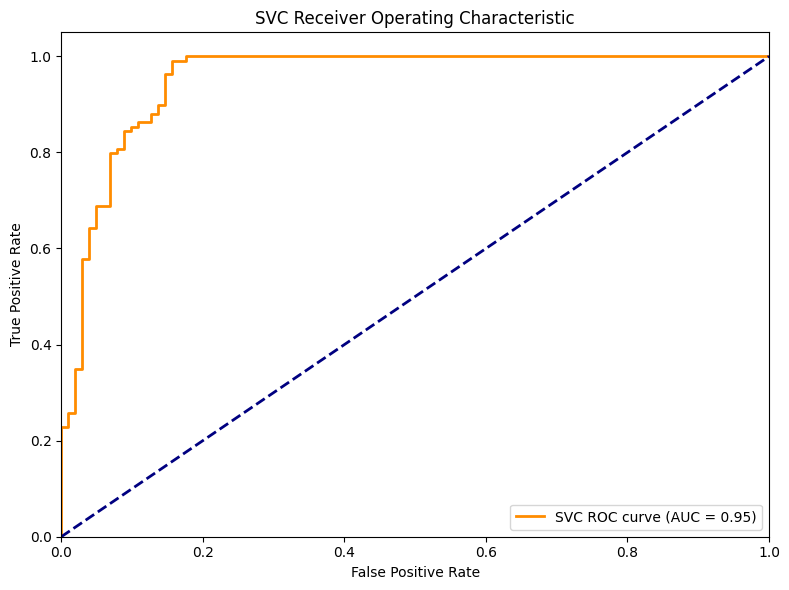

Misclassified Samples:
      Actual  Predicted  Probability_Class1
24        0          1            0.810865
30        0          1            0.872986
51        0          1            0.814404
59        0          1            0.750708
67        1          0            0.329412
69        0          1            0.828805
75        0          1            0.919662
100       0          1            0.702350
108       0          1            0.831005
114       0          1            0.740340
127       0          1            0.415793
131       0          1            0.775416
163       0          1            0.917004
167       0          1            0.567579
171       0          1            0.859488
181       0          1            0.858273
187       0          1            0.864639
210       0          1            0.907290


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc, roc_auc_score)

def svc_full_evaluation(X, y, test_size=0.2, random_state=42):
    """
    Full pipeline for SVC with scaling and ROC plotting.
    Prints evaluation, returns model/results/misclassifications.

    Parameters:
        X: feature matrix (DataFrame or ndarray)
        y: target (Series or ndarray)
        test_size: float, test split ratio
        random_state: int, for reproducibility

    Returns:
        svc_model: Trained SVC model
        results_df: DataFrame of actual, predicted, and probability
        misclassified: DataFrame of misclassified samples
    """
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train SVC
    svc_model = SVC(probability=True, random_state=random_state)
    svc_model.fit(X_train_scaled, y_train)

    # Predict on test set
    y_pred_svc = svc_model.predict(X_test_scaled)
    y_proba_svc = svc_model.predict_proba(X_test_scaled)[:, 1]

    # Evaluation
    print("SVC Test Accuracy:", accuracy_score(y_test, y_pred_svc))
    print("SVC Classification Report:\n", classification_report(y_test, y_pred_svc))
    print("SVC Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svc))
    print("SVC ROC AUC Score:", roc_auc_score(y_test, y_proba_svc))

    # Actual, predicted, and probability DataFrame
    results_df = pd.DataFrame({
        'Actual': y_test.values,
        'Predicted': y_pred_svc,
        'Probability_Class1': y_proba_svc
    })
    print("Sample Predictions:\n", results_df.head(20))

    # Plot ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_proba_svc)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'SVC ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('SVC Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    # Show misclassified samples
    misclassified = results_df[results_df['Actual'] != results_df['Predicted']]
    print("Misclassified Samples:\n", misclassified)

    return svc_model, results_df, misclassified

# Example usage:
svc_model, results_df, misclassified = svc_full_evaluation(X_selected, y_encoded)


### 📊 Gradient Boosting Regressor Evaluation Metrics

Gradient Boosting Test Accuracy: 0.9052132701421801
Gradient Boosting Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.85      0.90       102
           1       0.87      0.95      0.91       109

    accuracy                           0.91       211
   macro avg       0.91      0.90      0.90       211
weighted avg       0.91      0.91      0.90       211

Gradient Boosting Confusion Matrix:
 [[ 87  15]
 [  5 104]]
Gradient Boosting ROC AUC Score: 0.9646519158121964
Sample Gradient Boosting Predictions:
     Actual  Predicted  Probability_Class1
0        1          1            0.975497
1        0          0            0.094068
2        1          1            0.940252
3        1          1            0.965501
4        1          1            0.901765
5        0          0            0.024169
6        0          0            0.008614
7        1          1            0.669387
8        0          0            0.005851
9       

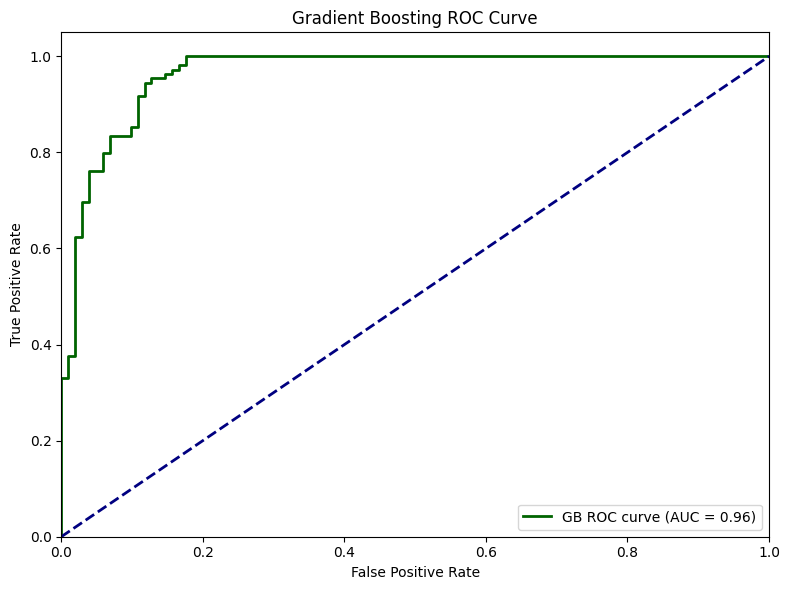

Misclassified (Gradient Boosting):
      Actual  Predicted  Probability_Class1
24        0          1            0.830476
30        0          1            0.786928
51        0          1            0.881912
59        0          1            0.613491
67        1          0            0.225343
69        0          1            0.501315
75        0          1            0.935060
100       0          1            0.711409
107       1          0            0.388947
108       0          1            0.534105
114       0          1            0.907143
141       1          0            0.337690
149       0          1            0.571634
163       0          1            0.967886
171       0          1            0.770499
181       0          1            0.788944
187       0          1            0.971099
189       1          0            0.455202
208       1          0            0.267636
210       0          1            0.884476


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             roc_curve, auc, roc_auc_score)

def gradient_boosting_full_evaluation(X, y, test_size=0.2, random_state=42):
    """
    Runs full Gradient Boosting workflow:
    - Splits and scales data
    - Trains model
    - Prints evaluation, plots ROC, returns model/results/misclassified

    Parameters:
        X: feature matrix (DataFrame or ndarray)
        y: target (Series or ndarray)
        test_size: float, test set proportion
        random_state: int, reproducibility

    Returns:
        gb_model: Fitted Gradient Boosting model
        results_gb: DataFrame of actual, predicted, and probabilities
        misclassified_gb: DataFrame of misclassified samples
    """
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Scale (optional but recommended)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train model
    gb_model = GradientBoostingClassifier(random_state=random_state)
    gb_model.fit(X_train_scaled, y_train)

    # Predict and probability
    y_pred_gb = gb_model.predict(X_test_scaled)
    y_proba_gb = gb_model.predict_proba(X_test_scaled)[:, 1]

    # Evaluation
    print("Gradient Boosting Test Accuracy:", accuracy_score(y_test, y_pred_gb))
    print("Gradient Boosting Classification Report:\n", classification_report(y_test, y_pred_gb))
    print("Gradient Boosting Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
    print("Gradient Boosting ROC AUC Score:", roc_auc_score(y_test, y_proba_gb))

    # Prediction DataFrame
    results_gb = pd.DataFrame({
        'Actual': y_test.values,
        'Predicted': y_pred_gb,
        'Probability_Class1': y_proba_gb
    })
    print("Sample Gradient Boosting Predictions:\n", results_gb.head(20))

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_proba_gb)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, color='darkgreen', lw=2, label=f'GB ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Gradient Boosting ROC Curve')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    # Misclassified samples
    misclassified_gb = results_gb[results_gb['Actual'] != results_gb['Predicted']]
    print("Misclassified (Gradient Boosting):\n", misclassified_gb)

    return gb_model, results_gb, misclassified_gb

# Example usage:
gb_model, results_gb, misclassified_gb = gradient_boosting_full_evaluation(X_selected, y_encoded)


### Ensemble Model

Ensemble Test Accuracy: 0.9052132701421801
Ensemble Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.85      0.90       102
           1       0.87      0.95      0.91       109

    accuracy                           0.91       211
   macro avg       0.91      0.90      0.90       211
weighted avg       0.91      0.91      0.90       211

Ensemble Confusion Matrix:
 [[ 87  15]
 [  5 104]]
Ensemble ROC AUC Score: 0.9656413023925166
Sample Ensemble Predictions:
     Actual  Predicted  Probability_Class1
0        1          1            0.892227
1        0          0            0.104526
2        1          1            0.897789
3        1          1            0.903182
4        1          1            0.873854
5        0          0            0.049026
6        0          0            0.008578
7        1          1            0.766131
8        0          0            0.010892
9        0          0            0.144289
10       0 

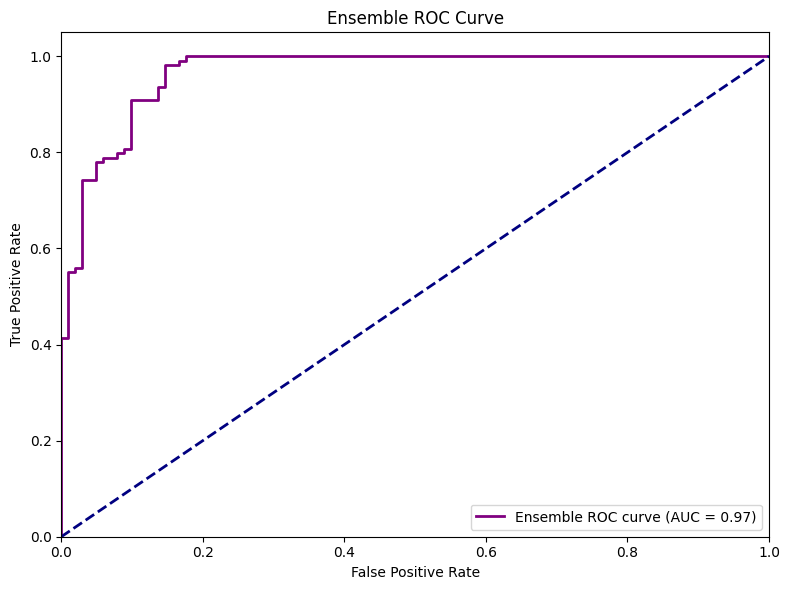

Misclassified (Ensemble):
      Actual  Predicted  Probability_Class1
24        0          1            0.800447
30        0          1            0.829971
51        0          1            0.808772
59        0          1            0.671400
67        1          0            0.314918
69        0          1            0.660040
75        0          1            0.931574
100       0          1            0.681253
107       1          0            0.496454
108       0          1            0.675036
114       0          1            0.805828
131       0          1            0.591781
141       1          0            0.466922
163       0          1            0.904963
171       0          1            0.786662
181       0          1            0.805739
187       0          1            0.908579
189       1          0            0.467577
208       1          0            0.381523
210       0          1            0.827255


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_curve, auc, roc_auc_score)

def voting_ensemble_full_evaluation(X, y, test_size=0.2, random_state=42):
    """
    Full workflow for a soft-voting ensemble of Random Forest, SVC, and GB.
    Splits, scales, trains, evaluates, and plots ROC, returns results.

    Parameters:
        X: features (DataFrame or ndarray)
        y: target
        test_size: float, test set proportion
        random_state: int

    Returns:
        ensemble: trained VotingClassifier
        results_ens: DataFrame with actual, predicted, and probabilities
        misclassified_ens: DataFrame of misclassifications
    """
    # Split and scale data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Base models
    rf_model = RandomForestClassifier(random_state=random_state)
    svc_model = SVC(probability=True, random_state=random_state)
    gb_model = GradientBoostingClassifier(random_state=random_state)

    # Ensemble
    ensemble = VotingClassifier(
        estimators=[
            ('rf', rf_model),
            ('svc', svc_model),
            ('gb', gb_model)
        ],
        voting='soft'
    )
    ensemble.fit(X_train_scaled, y_train)

    # Predict and probability
    y_pred_ens = ensemble.predict(X_test_scaled)
    y_proba_ens = ensemble.predict_proba(X_test_scaled)[:, 1]

    # Evaluation
    print("Ensemble Test Accuracy:", accuracy_score(y_test, y_pred_ens))
    print("Ensemble Classification Report:\n", classification_report(y_test, y_pred_ens))
    print("Ensemble Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ens))
    print("Ensemble ROC AUC Score:", roc_auc_score(y_test, y_proba_ens))

    # Prediction DataFrame
    results_ens = pd.DataFrame({
        'Actual': y_test.values,
        'Predicted': y_pred_ens,
        'Probability_Class1': y_proba_ens
    })
    print("Sample Ensemble Predictions:\n", results_ens.head(20))

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_proba_ens)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, color='purple', lw=2, label=f'Ensemble ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Ensemble ROC Curve')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    # Misclassified samples
    misclassified_ens = results_ens[results_ens['Actual'] != results_ens['Predicted']]
    print("Misclassified (Ensemble):\n", misclassified_ens)

    return ensemble, results_ens, misclassified_ens

# Example usage:
ensemble, results_ens, misclassified_ens = voting_ensemble_full_evaluation(X_selected, y_encoded)


Ensemble Test Accuracy: 0.9052132701421801
Ensemble Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.85      0.90       102
           1       0.87      0.95      0.91       109

    accuracy                           0.91       211
   macro avg       0.91      0.90      0.90       211
weighted avg       0.91      0.91      0.90       211

Ensemble Confusion Matrix:
 [[ 87  15]
 [  5 104]]
Ensemble ROC AUC Score: 0.9656413023925166
Sample Ensemble Predictions:
     Actual  Predicted  Probability_Class1
0        1          1            0.892227
1        0          0            0.104526
2        1          1            0.897789
3        1          1            0.903182
4        1          1            0.873854
5        0          0            0.049026
6        0          0            0.008578
7        1          1            0.766131
8        0          0            0.010892
9        0          0            0.144289
10       0 

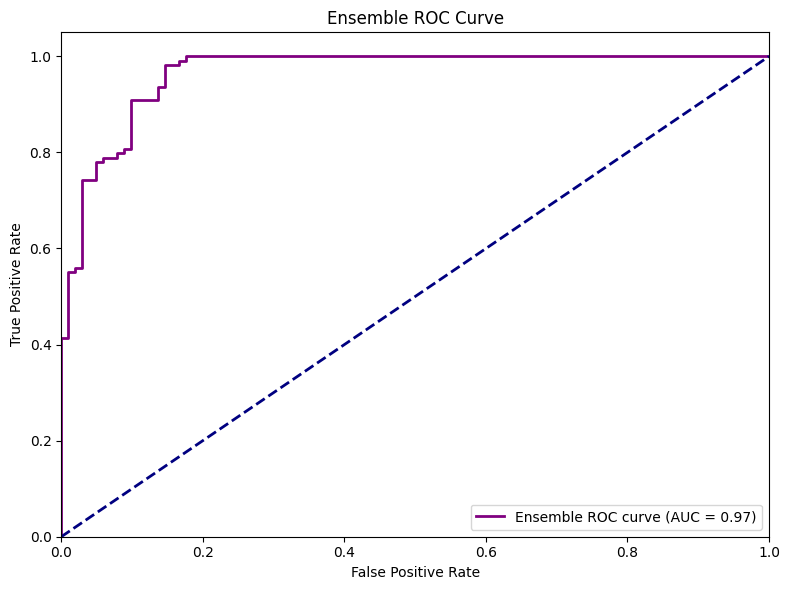

Misclassified (Ensemble):
      Actual  Predicted  Probability_Class1
24        0          1            0.800447
30        0          1            0.829971
51        0          1            0.808772
59        0          1            0.671400
67        1          0            0.314918
69        0          1            0.660040
75        0          1            0.931574
100       0          1            0.681253
107       1          0            0.496454
108       0          1            0.675036
114       0          1            0.805828
131       0          1            0.591781
141       1          0            0.466922
163       0          1            0.904963
171       0          1            0.786662
181       0          1            0.805739
187       0          1            0.908579
189       1          0            0.467577
208       1          0            0.381523
210       0          1            0.827255


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, roc_auc_score

def ensemble_full_evaluation(X, y, test_size=0.2, random_state=42):
    # Split and scale data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define base models
    rf_model = RandomForestClassifier(random_state=random_state)
    svc_model = SVC(probability=True, random_state=random_state)
    gb_model = GradientBoostingClassifier(random_state=random_state)

    # Soft-voting ensemble
    ensemble = VotingClassifier(
        estimators=[
            ('rf', rf_model),
            ('svc', svc_model),
            ('gb', gb_model)
        ],
        voting='soft'
    )
    ensemble.fit(X_train_scaled, y_train)

    # Predict, probabilities, and evaluation
    y_pred_ens = ensemble.predict(X_test_scaled)
    y_proba_ens = ensemble.predict_proba(X_test_scaled)[:, 1]

    print("Ensemble Test Accuracy:", accuracy_score(y_test, y_pred_ens))
    print("Ensemble Classification Report:\n", classification_report(y_test, y_pred_ens))
    print("Ensemble Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ens))
    print("Ensemble ROC AUC Score:", roc_auc_score(y_test, y_proba_ens))

    # Prediction DataFrame
    results_ens = pd.DataFrame({
        'Actual': y_test.values,
        'Predicted': y_pred_ens,
        'Probability_Class1': y_proba_ens
    })
    print("Sample Ensemble Predictions:\n", results_ens.head(20))

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_proba_ens)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, color='purple', lw=2, label=f'Ensemble ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Ensemble ROC Curve')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    # Misclassified samples
    misclassified_ens = results_ens[results_ens['Actual'] != results_ens['Predicted']]
    print("Misclassified (Ensemble):\n", misclassified_ens)
    return ensemble, results_ens, misclassified_ens

# Example usage:
ensemble, results_ens, misclassified_ens = ensemble_full_evaluation(X_selected, y_encoded)


Class mapping: {0: 'Benign', 1: 'Malignant'}

Comparison of Model Predictions (first 10 rows):
   Actual  SVC_Pred  RF_Pred  GBC_Pred  Ensemble_Pred
0       0         0        0         0              0
1       1         1        1         1              1
2       0         0        0         0              0
3       0         0        0         0              0
4       0         0        0         0              0
5       1         1        1         1              1
6       1         1        1         1              1
7       0         0        0         0              0
8       1         1        1         1              1
9       1         1        1         1              1

SVC Report:
               precision    recall  f1-score   support

           0       0.85      0.94      0.89       109
           1       0.92      0.82      0.87       102

    accuracy                           0.88       211
   macro avg       0.89      0.88      0.88       211
weighted avg       0.89  

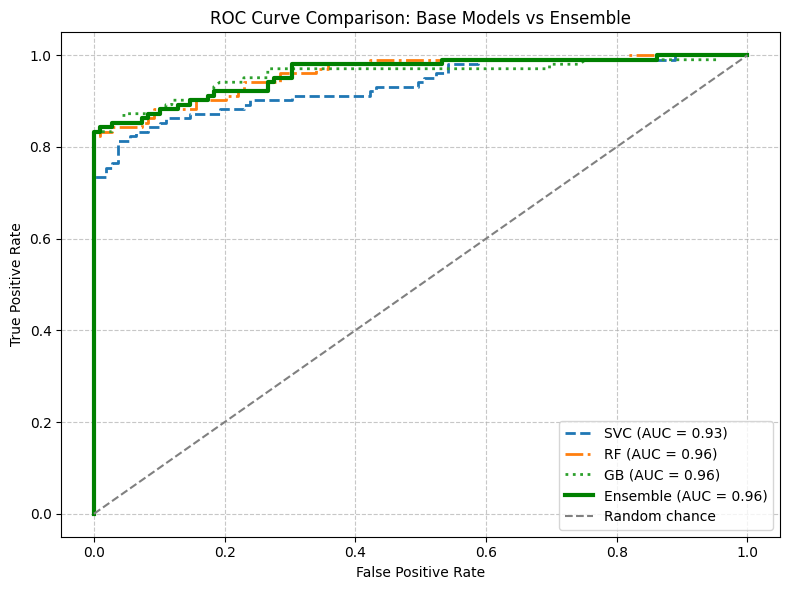


First 5 Actual vs Ensemble Predicted:
    Actual  Predicted
0       0          0
1       1          1
2       0          0
3       0          0
4       0          0


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix, roc_curve)
import matplotlib.pyplot as plt

# 1. LOAD and PREPROCESS DATA
df = pd.read_excel("merged_breast_cancer_data.xlsx")  # e.g., "merged_breast_cancer_data.xlsx"
target_col = 'categories'     # adjust to your target column
drop_cols = ['findings']      # columns to remove if exist

# Drop missing target
df = df.dropna(subset=[target_col])

# Drop unused columns
for col in drop_cols:
    if col in df.columns:
        df = df.drop(columns=[col])

# Feature matrix and encoded target
X = pd.get_dummies(df.drop(columns=[target_col]), drop_first=True)
y, uniques = pd.factorize(df[target_col])
print("Class mapping:", dict(enumerate(uniques)))

# 2. TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. FEATURE SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. RANDOMIZED RF FITTING (hyperparameter search, optional but best-practice)
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist, n_iter=10, cv=3, n_jobs=-1, verbose=0, random_state=42
)
rf_search.fit(X_train_scaled, y_train)

# 5. ENSEMBLE DEFINITION & EVALUATION FUNCTION
def evaluate_voting_ensemble(X_train, X_test, y_train, y_test, best_rf=None):
    svc_model = SVC(probability=True, random_state=42)
    rf_model = best_rf if best_rf is not None else RandomForestClassifier(n_estimators=100, random_state=42)
    gbc_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

    svc_model.fit(X_train, y_train)
    rf_model.fit(X_train, y_train)
    gbc_model.fit(X_train, y_train)

    ensemble = VotingClassifier(
        estimators=[('svc', svc_model), ('rf', rf_model), ('gbc', gbc_model)],
        voting='soft'
    )
    ensemble.fit(X_train, y_train)

    y_pred_svc = svc_model.predict(X_test)
    y_pred_rf  = rf_model.predict(X_test)
    y_pred_gbc = gbc_model.predict(X_test)
    y_pred_ens = ensemble.predict(X_test)
    y_prob_svc = svc_model.predict_proba(X_test)[:, 1]
    y_prob_rf  = rf_model.predict_proba(X_test)[:, 1]
    y_prob_gbc = gbc_model.predict_proba(X_test)[:, 1]
    y_prob_ens = ensemble.predict_proba(X_test)[:, 1]

    actual = pd.Series(y_test).values
    prediction_df = pd.DataFrame({
        'Actual': actual,
        'SVC_Pred': y_pred_svc,
        'RF_Pred': y_pred_rf,
        'GBC_Pred': y_pred_gbc,
        'Ensemble_Pred': y_pred_ens
    })
    print("\nComparison of Model Predictions (first 10 rows):")
    print(prediction_df.head(10).to_string(index=True))

    print("\nSVC Report:\n", classification_report(y_test, y_pred_svc))
    print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))
    print("Gradient Boost Report:\n", classification_report(y_test, y_pred_gbc))
    print("Ensemble Report:\n", classification_report(y_test, y_pred_ens))

    auc_svc = roc_auc_score(y_test, y_prob_svc)
    auc_rf = roc_auc_score(y_test, y_prob_rf)
    auc_gbc = roc_auc_score(y_test, y_prob_gbc)
    auc_ens = roc_auc_score(y_test, y_prob_ens)
    print(f"SVC ROC AUC: {auc_svc:.4f}")
    print(f"RF ROC AUC: {auc_rf:.4f}")
    print(f"GBC ROC AUC: {auc_gbc:.4f}")
    print(f"Ensemble ROC AUC: {auc_ens:.4f}")

    cm = confusion_matrix(y_test, y_pred_ens)
    print("\nEnsemble Confusion Matrix:\n", cm)

    fpr_svc, tpr_svc, _ = roc_curve(y_test, y_prob_svc)
    fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
    fpr_gbc, tpr_gbc, _ = roc_curve(y_test, y_prob_gbc)
    fpr_ens, tpr_ens, _ = roc_curve(y_test, y_prob_ens)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_svc, tpr_svc, lw=2, label=f'SVC (AUC = {auc_svc:.2f})', linestyle='--')
    plt.plot(fpr_rf, tpr_rf, lw=2, label=f'RF (AUC = {auc_rf:.2f})', linestyle='-.')
    plt.plot(fpr_gbc, tpr_gbc, lw=2, label=f'GB (AUC = {auc_gbc:.2f})', linestyle=':')
    plt.plot(fpr_ens, tpr_ens, lw=3, color='green', label=f'Ensemble (AUC = {auc_ens:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison: Base Models vs Ensemble')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    comparison_df = pd.DataFrame({
        'Actual': actual[:5],
        'Predicted': y_pred_ens[:5]
    })
    print("\nFirst 5 Actual vs Ensemble Predicted:\n", comparison_df)

    results = {
        "svc_model": svc_model,
        "rf_model": rf_model,
        "gbc_model": gbc_model,
        "ensemble": ensemble,
        "auc_scores": {
            "svc": auc_svc,
            "rf": auc_rf,
            "gbc": auc_gbc,
            "ensemble": auc_ens
        },
        "confusion_matrix": cm,
        "prediction_table": prediction_df
    }
    return results

# 6. RUN THE ENSEMBLE EVALUATION
results = evaluate_voting_ensemble(X_train_scaled, X_test_scaled, y_train, y_test, best_rf=rf_search.best_estimator_)
